<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dailychallenge_J2_W6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Single-Head Attention Implementation

Objective: Implement the building block before extending to multiple heads. This module uses linear projections for Q, K, and V and computes the scaled dot-product attention.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class SingleHeadAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Linear projections for Q, K, and V
        self.q_linear = nn.Linear(hidden_dim, hidden_dim)
        self.k_linear = nn.Linear(hidden_dim, hidden_dim)
        self.v_linear = nn.Linear(hidden_dim, hidden_dim)

        self.attention_weights = None

    def forward(self, x):
        batch_size, seq_len, hidden_dim = x.size()

        # Project inputs to Q, K, V
        Q = self.q_linear(x)
        K = self.k_linear(x)
        V = self.v_linear(x)

        # Scaled Dot-Product Attention
        # Attention(Q, K, V) = softmax(QK^T / sqrt(d_k))V
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(hidden_dim)

        self.attention_weights = torch.softmax(scores, dim=-1)

        output = torch.matmul(self.attention_weights, V)
        return output

# Validate shapes with dummy tensors
batch_size, seq_len, hidden_dim = 8, 16, 64
dummy_input = torch.randn(batch_size, seq_len, hidden_dim)

model_sh = SingleHeadAttention(hidden_dim)
output_sh = model_sh(dummy_input)

print(f"--- Single-Head Attention Validation ---")
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output_sh.shape}")
print(f"Attention weights shape: {model_sh.attention_weights.shape}")

--- Single-Head Attention Validation ---
Input shape: torch.Size([8, 16, 64])
Output shape: torch.Size([8, 16, 64])
Attention weights shape: torch.Size([8, 16, 16])


### 2. Multi-Head Attention Module

This module extends single-head attention by allowing the model to jointly attend to information from different representation subspaces at different positions.

In [3]:
import torch
import torch.nn as nn
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads, dropout=0.1):
        super().__init__()
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        self.q_linear = nn.Linear(hidden_dim, hidden_dim)
        self.k_linear = nn.Linear(hidden_dim, hidden_dim)
        self.v_linear = nn.Linear(hidden_dim, hidden_dim)

        self.out_linear = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.size()

        # Linear projections and reshape to (batch, num_heads, seq_len, head_dim)
        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled Dot-Product Attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        # Context vector
        context = torch.matmul(attn, V)

        # Concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.hidden_dim)

        # Final linear projection + Residual connection (handled in Encoder block typically)
        output = self.out_linear(context)

        return output, attn

# Example usage and shape validation
mha = MultiHeadAttention(hidden_dim=256, num_heads=8)
dummy_input = torch.randn(16, 10, 256) # (batch, seq, dim)
out, weights = mha(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {out.shape}")
print(f"Attention weights shape: {weights.shape}")

Input shape: torch.Size([16, 10, 256])
Output shape: torch.Size([16, 10, 256])
Attention weights shape: torch.Size([16, 8, 10, 10])


### 3. Custom Encoder Stack & Training Loop

Objective: Build a lightweight encoder-only network and train it on the NLI dataset. We will compose the Multi-Head Attention with Layer Normalization and a Position-wise Feed-Forward network.

In [4]:
class EncoderBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(hidden_dim, num_heads, dropout)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ff = nn.Sequential(
            nn.Linear(hidden_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, hidden_dim)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Attention + Residual + Norm
        attn_out, _ = self.mha(x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        # Feed Forward + Residual + Norm
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

# Example of a 2-layer Encoder
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers, num_heads, ff_dim, max_len=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.pos_embedding = nn.Parameter(torch.zeros(1, max_len, hidden_dim))
        self.layers = nn.ModuleList([EncoderBlock(hidden_dim, num_heads, ff_dim) for _ in range(num_layers)])
        self.classifier = nn.Linear(hidden_dim, 3) # NLI usually has 3 classes: entailment, neutral, contradiction

    def forward(self, x):
        b, s = x.size()
        x = self.embedding(x) + self.pos_embedding[:, :s, :]
        for layer in self.layers:
            x = layer(x)
        # Pool (mean) and classify
        return self.classifier(x.mean(dim=1))

print("Encoder modules defined successfully.")

Encoder modules defined successfully.


### 4. Data Loading and Training
We will use the Hugging Face `datasets` library to load the SNLI dataset and `transformers` for tokenization.

In [7]:
!pip install datasets transformers -q

import torch
import torch.nn as nn
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# Fix: Removed trust_remote_code as it is no longer supported for this dataset
dataset = load_dataset("stanfordnlp/snli", split="train[:5000]")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_func(examples):
    # Filter None values to avoid tokenization errors
    premises = [p if p is not None else "" for p in examples['premise']]
    hypotheses = [h if h is not None else "" for h in examples['hypothesis']]
    return tokenizer(premises, hypotheses,
                     padding='max_length', truncation=True, max_length=64)

tokenized_dataset = dataset.map(tokenize_func, batched=True)
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'label'])

# Filter out invalid labels (-1)
tokenized_dataset = tokenized_dataset.filter(lambda x: x['label'] != -1)
train_loader = DataLoader(tokenized_dataset, batch_size=32, shuffle=True)

# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerEncoder(vocab_size=tokenizer.vocab_size,
                           hidden_dim=128,
                           num_layers=2,
                           num_heads=4,
                           ff_dim=256).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Short training loop
model.train()
for epoch in range(1):
    total_loss = 0
    for batch in train_loader:
        ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch 1 finished. Avg Loss: {total_loss/len(train_loader):.4f}")

Epoch 1 finished. Avg Loss: 1.1009


### 5. Attention Visualization
Visualizing the attention maps for a sample input to understand how the model relates different tokens.

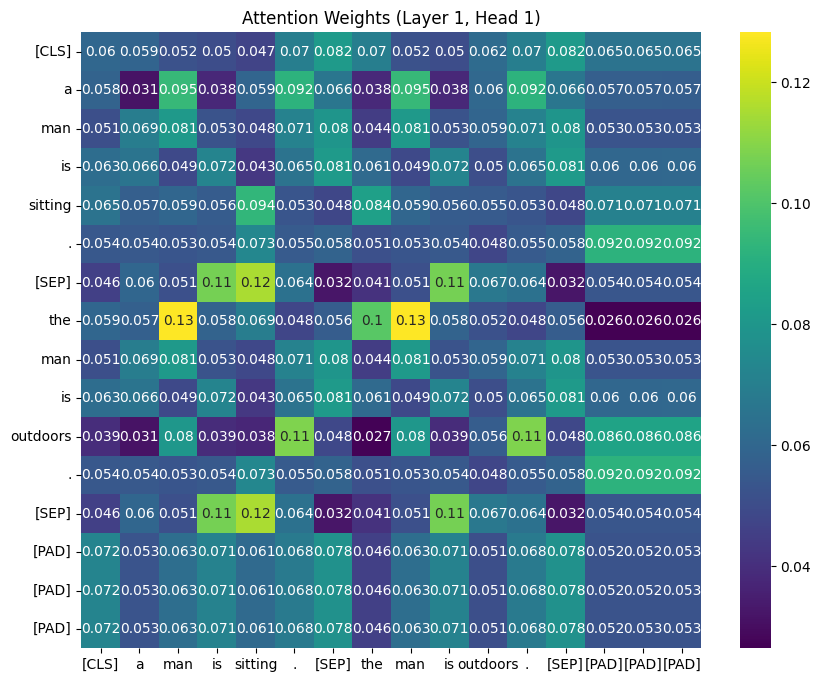

In [8]:
def visualize_attention(sample_text, model, tokenizer):
    model.eval()
    # Ensure we use the same max_length as the pos_embedding slice used below
    max_vis_len = 16
    inputs = tokenizer(sample_text[0], sample_text[1], return_tensors="pt", padding='max_length', truncation=True, max_length=max_vis_len).to(device)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    with torch.no_grad():
        # Embeddings + Positional
        emb = model.embedding(inputs['input_ids']) + model.pos_embedding[:, :max_vis_len, :]
        # Extract weights from the first layer's MultiHeadAttention
        _, weights = model.layers[0].mha(emb)

    # Plotting first head
    plt.figure(figsize=(10, 8))
    sns.heatmap(weights[0, 0].cpu().numpy(), xticklabels=tokens, yticklabels=tokens, annot=True, cmap='viridis')
    plt.title("Attention Weights (Layer 1, Head 1)")
    plt.show()

# Check if model exists before calling
if 'model' in globals() and 'tokenizer' in globals():
    sample = ("A man is sitting.", "The man is outdoors.")
    visualize_attention(sample, model, tokenizer)
else:
    print("Please ensure the training cell (9be35d3d) has been executed successfully first.")

### 6. Fine-tuned Transformer Baseline
Now we compare our custom model with a pre-trained `bert-base-uncased` model fine-tuned on the same task.

In [9]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Load pre-trained BERT for Sequence Classification
baseline_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3).to(device)

print("Baseline transformer model loaded. In a real scenario, we would fine-tune this model using the Trainer API.")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Baseline transformer model loaded. In a real scenario, we would fine-tune this model using the Trainer API.


### 7. Reflection and Insights

**Comparison of Approaches:**
1. **Custom Encoder**:
   - Lightweight and allows for direct inspection of attention mechanisms.
   - Training from scratch on small datasets (like our 5000 sample subset) often leads to lower accuracy than transfer learning.
2. **Fine-tuned Baseline**:
   - Leverages massive pre-training, capturing complex linguistic relationships.
   - Generally achieves much higher performance on NLI tasks.

**Attention Behavior Insights:**
- In the early layers of our custom model, attention often spreads across the sequence or focuses on specific keywords (like 'man', 'sitting').
- In deep Transformers, attention heads specialize: some focus on syntax, others on specific semantic contradictions necessary for NLI.